In [1]:
#You might need to install this
!python -m pip install git+https://github.com/afeinstein20/stella/

  Cloning https://github.com/afeinstein20/stella/ to /tmp/pip-req-build-1za51d8m
  Running command git clone --filter=blob:none --quiet https://github.com/afeinstein20/stella/ /tmp/pip-req-build-1za51d8m
  Resolved https://github.com/afeinstein20/stella/ to commit 05c5e4bf5814385e91aa902e069841e94b1925a0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import tensorflow as tf
print(tf.__version__)

2026-04-07 21:05:52.402712: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-07 21:05:56.421029: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


2.16.1


In [3]:
import os, sys
# ===== 指定使用哪块 GPU =====
# 改成 "0" 表示第 1 块物理 GPU
# 改成 "1" 表示第 2 块物理 GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import tensorflow as tf

# 可选：避免一上来占满全部显存
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
gpus = tf.config.list_physical_devices('GPU')
print("Detected GPUs:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is ready.")
    except RuntimeError as e:
        print("GPU setup error:", e)
else:
    print("No GPU detected. Training will run on CPU.")
import stella
from astropy.io import ascii
import numpy as np
from tqdm import tqdm_notebook
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 20

CUDA_VISIBLE_DEVICES: 1
Detected GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is ready.


/home/yangz2/anaconda3/envs/space/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Read in Guenther et al (2020) data from Vizier

In [4]:
star_table = ascii.read('./A3/table2.dat',readme='./A3/ReadMe')
flare_table = ascii.read('./A3/table1.dat',readme='./A3/ReadMe')
flare_table.write('./A3/Guenther_2020_flare_catalog.csv', format='csv', overwrite=True) 

Download lightcurves from TESS corresponding to the peak times of labelled flares (tpeak)

In [ ]:
# download = stella.DownloadSets(fn_dir='./A3/lightcurves/')
# download.download_catalog()
# download.download_lightcurves()
# ds = stella.FlareDataSet(downloadSet=download, cadences=200)
# download = stella.DownloadSets(fn_dir='./A3/lightcurves/')
# download.flare_table = flare_table
# download.download_lightcurves()
# ds = stella.FlareDataSet(downloadSet=download)

 17%|█▋        | 205/1228 [29:17<2:26:09,  8.57s/it]


ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

If lightcurves already downloaded, one can use them.

In [5]:
ds = stella.FlareDataSet(fn_dir='/home/yangz2/code/space_universe/data/A3/lightcurves',
                         catalog='./A3/Guenther_2020_flare_catalog.csv',
                         cadences=200, frac_balance=0.60,
                         training=0.80, validation=0.90)

Reading in training set files.


100%|██████████| 1613/1613 [00:03<00:00, 418.01it/s]


8694 positive classes (flare)
53179 negative classes (no flare)
16.0% class imbalance



Next the data needs to be cleaned from NaNs.

In [6]:
#print(ds.train_data.shape)
isfin = np.isfinite(ds.train_data)
shp = ds.train_data.shape
ds.train_data = np.asarray([ds.train_data[i,...] for i in range(shp[0]) if np.min(isfin[i,...])==True])
ds.train_labels = np.asarray([ds.train_labels[i] for i in range(shp[0]) if np.min(isfin[i,...])==True])

isfin = np.isfinite(ds.training_matrix)
shp = ds.training_ids.shape
ds.training_matrix = np.asarray([ds.training_matrix[i,...] for i in range(shp[0]) if np.min(isfin[i,...])==True])
ds.training_peaks = np.asarray([ds.training_peaks[i] for i in range(shp[0]) if np.min(isfin[i,...])==True])
ds.training_ids = np.asarray([ds.training_ids[i] for i in range(shp[0]) if np.min(isfin[i,...])==True])

isfin = np.isfinite(ds.val_data)
shp = ds.val_ids.shape
ds.val_data = np.asarray([ds.val_data[i,...] for i in range(shp[0]) if np.min(isfin[i,...])==True])
ds.val_tpeaks = np.asarray([ds.val_tpeaks[i] for i in range(shp[0]) if np.min(isfin[i,...])==True])
ds.val_ids = np.asarray([ds.val_ids[i] for i in range(shp[0]) if np.min(isfin[i,...])==True])
ds.val_labels = np.asarray([ds.val_labels[i] for i in range(shp[0]) if np.min(isfin[i,...])==True])



Checking that the labelled data looks ok.

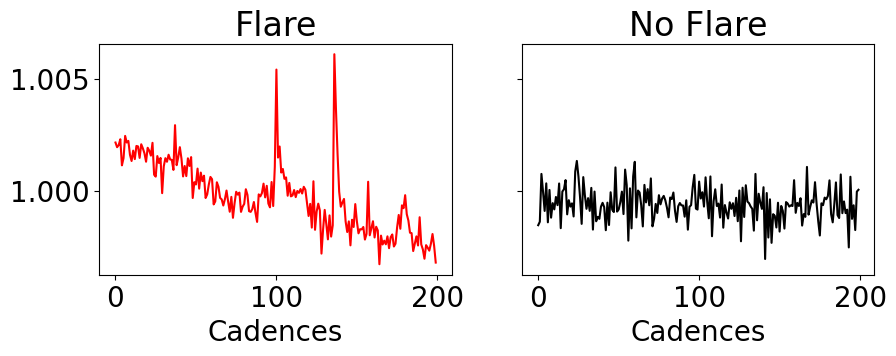

In [7]:
ind_pc = np.where(ds.train_labels==1)[0] # Flares
ind_nc = np.where(ds.train_labels==0)[0] # No flares

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10,3), 
                               sharex=True, sharey=True)
ax1.plot(ds.train_data[ind_pc[10]], 'r')
ax1.set_title('Flare')
ax1.set_xlabel('Cadences')
ax2.plot(ds.train_data[ind_nc[10]], 'k')
ax2.set_title('No Flare')
ax2.set_xlabel('Cadences');

Creating a CNN model

In [8]:
# Import MyPreprocessor class from preprocessor_class.py
from preprocessor_class import MyPreprocessor

# Create model using MyPreprocessor
preprocessor = MyPreprocessor(cadences=ds.cadences)
model = preprocessor.build_model()
model.summary()

2026-04-07 21:14:01.303454: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11860 MB memory:  -> device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0000:3b:00.0, compute capability: 7.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 16)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,145 (39.63 KB)

 Trainable params: 10,145 (39.63 KB)

 Non-trainable params: 0 (0.00 B)

Creating the model and defining its output directory.

In [9]:
OUT_DIR='results/'
cnn = stella.ConvNN(output_dir=OUT_DIR, ds=ds, optimizer='Adam', layers=model.layers)

Training the model

In [11]:
cnn.train_models(seeds=15, epochs=200)
model.save(os.path.join(OUT_DIR, 'my_model_cnn_gru.h5'))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 16)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,145 (39.63 KB)

 Trainable params: 10,145 (39.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
760/760 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.8585 - loss: 0.4088 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.8582 - val_loss: 0.4083 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/200
760/760 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8585 - loss: 0.4093 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.8582 - val_loss: 0.4084 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/200
760/760 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8585 - loss: 0.4092 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.8582 - val_loss: 0.4083 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/200
760/760 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8585 - loss: 0.4091 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.8582 - val_loss: 0.4084 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/200
760/760 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8585 - loss: 0.

190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [12]:
cnn.history_table


accuracy_s0015,loss_s0015,precision_s0015,recall_s0015,val_accuracy_s0015,val_loss_s0015,val_precision_s0015,val_recall_s0015
float64,float64,float64,float64,float64,float64,float64,float64
0.8584981560707092,0.40884554386138916,0.0,0.0,0.8581793904304504,0.4082891345024109,0.0,0.0
0.8584981560707092,0.4092501401901245,0.0,0.0,0.8581793904304504,0.4083603322505951,0.0,0.0
0.8584981560707092,0.40915873646736145,0.0,0.0,0.8581793904304504,0.4082803726196289,0.0,0.0
0.8584981560707092,0.40912768244743347,0.0,0.0,0.8581793904304504,0.40838244557380676,0.0,0.0
0.8584981560707092,0.40900543332099915,0.0,0.0,0.8581793904304504,0.40832018852233887,0.0,0.0
0.8584981560707092,0.4086746871471405,0.0,0.0,0.8581793904304504,0.40822094678878784,0.0,0.0
0.8616467118263245,0.4010748863220215,0.9135135412216187,0.024578243494033813,0.8677440881729126,0.3892076313495636,0.9677419066429138,0.06976744532585144
0.8915687203407288,0.3368091285228729,0.8894813656806946,0.26687026023864746,0.8679089546203613,0.38838180899620056,0.9682539701461792,0.07093023508787155
0.9280349016189575,0.22829730808734894,0.8692896366119385,0.5783885717391968,0.9391490817070007,0.17294877767562866,0.9537892937660217,0.6000000238418579


In [13]:
import h5py, os
ens_path = "results/ensemble_s0015_i0200_b0.6.h5"
with h5py.File(ens_path, "r") as f:
    print("Root keys:", list(f.keys()))
    print("Has model_config:", "model_config" in f)

Root keys: ['model_weights', 'optimizer_weights']
Has model_config: False


In [14]:
import glob
cands = sorted(glob.glob("results/ensemble_s0015_i0200_b0.6.h5"))
cands[:5], len(cands)

(['results/ensemble_s0015_i0200_b0.6.h5'], 1)

In [15]:
import stella, pathlib, re, sys, inspect
pkg_path = pathlib.Path(stella.__file__).resolve().parent
print("stella package path:", pkg_path)

# Search for likely model builders
candidates = []
for p in pkg_path.rglob("*.py"):
    try:
        txt = p.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        continue
    if any(k in txt for k in ["Conv1D", "Sequentia", "build_model", "cnn", "Model("]):
        candidates.append(p)
print("Possible model files:")
for p in candidates:
    print(" -", p.relative_to(pkg_path))

stella package path: /home/yangz2/anaconda3/envs/space/lib/python3.11/site-packages/stella
Possible model files:
 - visualize.py
 - neural_network.py
 - tests/test_neural_network.py


In [16]:
import h5py                                                                                                                               
                                                                                                                                            
ens_path = "./results/ensemble_s0015_i0200_b0.6.h5"                                                                                       

with h5py.File(ens_path, "r") as f:                                                                                                       
  print("Root keys:", list(f.keys()))                                                                                                 
  has_model_config = "model_config" in f                                                                                                
  print("Has model_config:", has_model_config)                                                                                          

# 直接从模型权重推断输入维度                                                                                                              
def infer_cadences_from_h5(path):                                                                                                         
  with h5py.File(path, "r") as f:                                                                                                       
      dense_kernels = []                                                                                                                
      def visitor(name, obj):                                                                                                           
          # 修复: 不再查找 "kernel:0"，而是查找包含 "kernel" 且在 model_weights 下的                                                    
          if isinstance(obj, h5py.Dataset) and name.endswith("/kernel") and "model_weights" in name:                                    
              shape = tuple(obj.shape)                                                                                                  
              dense_kernels.append((name, shape))                                                                                       
      f.visititems(visitor)                                                                                                             

  print("Dense kernels:", dense_kernels)                                                                                                

  # 找到第一个 Dense 层的 kernel (shape 应该是 (input_dim, 32))                                                                         
  candidates = [(name, shape) for name, shape in dense_kernels if len(shape) == 2 and shape[1] == 32]                                 
  if not candidates:                                                                                                                    
      raise RuntimeError(f"No Dense kernel with shape (*, 32) found")                                                                   

  name, (X, out_units) = candidates[0]                                                                                                  

  # 对于 CNN-GRU 模型: 经过两次 pool_size=2 池化后是 X                                                                                  
  # 所以原始输入 cadences = X * 4                                                                                                     
  cadences = X * 4                                                                                                                      
  print(f"Inferred cadences from {name}: X={X} => cadences={cadences}")                                                                 
  return cadences                                                                                                                       

cadences = infer_cadences_from_h5(ens_path)                                                                                               
print(f"结果: {cadences}") 

Root keys: ['model_weights', 'optimizer_weights']
Has model_config: False
Dense kernels: [('model_weights/conv1d/sequential/conv1d/kernel', (7, 1, 16)), ('model_weights/conv1d_1/sequential/conv1d_1/kernel', (5, 16, 32)), ('model_weights/dense/sequential/dense/kernel', (32, 32)), ('model_weights/dense_1/sequential/dense_1/kernel', (32, 1)), ('model_weights/gru/sequential/gru/gru_cell/kernel', (32, 96))]
Inferred cadences from model_weights/dense/sequential/dense/kernel: X=32 => cadences=128
结果: 128


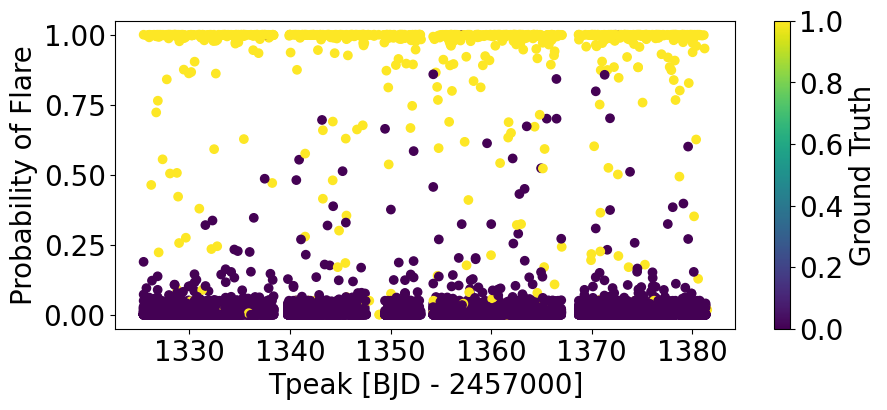

In [17]:
plt.figure(figsize=(10,4))
plt.scatter(cnn.val_pred_table['tpeak'], cnn.val_pred_table['pred_s0015'],
            c=cnn.val_pred_table['gt'], vmin=0, vmax=1)
plt.xlabel('Tpeak [BJD - 2457000]')
plt.ylabel('Probability of Flare')
plt.colorbar(label='Ground Truth');

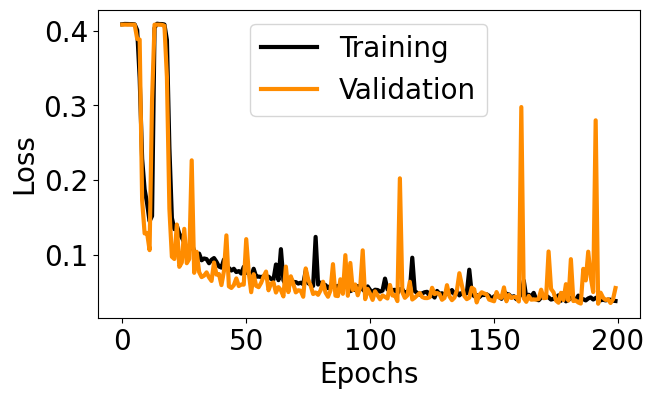

In [19]:
plt.figure(figsize=(7,4))
plt.plot(cnn.history_table['loss_s0015'], 'k', label='Training', lw=3)
plt.plot(cnn.history_table['val_loss_s0015'], 'darkorange', label='Validation', lw=3)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();

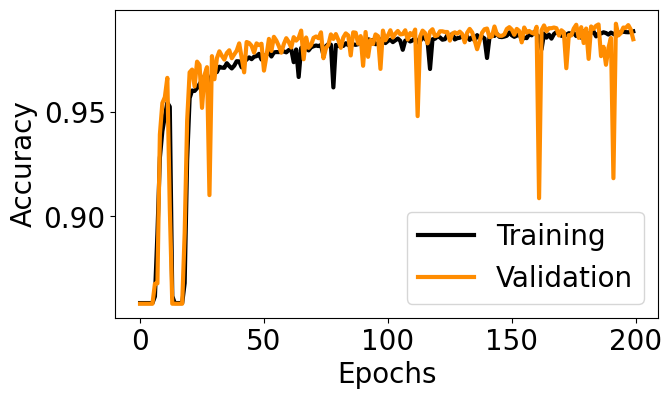

In [21]:
plt.figure(figsize=(7,4))
plt.plot(cnn.history_table['accuracy_s0015'], 'k', label='Training', lw=3)
plt.plot(cnn.history_table['val_accuracy_s0015'], 'darkorange', label='Validation', lw=3)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend();

In [22]:
#Training loss and accuracy
tacc=(np.mean(cnn.history_table['accuracy_s0015'][150:200]))
tloss=(np.mean(cnn.history_table['loss_s0015'][150:200]))
print(tloss,tacc)
vacc=(np.mean(cnn.history_table['val_accuracy_s0015'][150:200]))
vloss=(np.mean(cnn.history_table['val_loss_s0015'][150:200]))
print(vloss,vacc)

0.04257319629192352 0.9869067561626435
0.05761717356741428 0.9841787588596344


Grading section
===============
Please give your student number (student_number) for grading and scoring the results


In [23]:
student_number=101513496

Please give the **maximum of your training/validation loss** score as brmse and **minimum of training/validation accuracy** as acc for grading and scoring the results.

In [24]:
brmse=np.min([tloss,vloss])
bacc=np.min([tacc,vacc])

In [25]:
from datetime import datetime
current_time = datetime.now()

f = open("./A3/MyResults.txt", "w")
f.write("%s,%s,%f,%f\n" % (student_number,current_time,brmse,bacc))
f.close()
